# **Hands-On 1: Getting Familiar with KGEs**

In this first Hands-On session, we will get familiar with KGEs by using the PyKEEN library. We will explore how KGEs are trained by using different models, their evaluation, and how KGEs can be exploited once obtained.

## Step 0: Installation and libraries

In [1]:
!pip install pykeen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 33.9 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


from pykeen.datasets import Nations, CoDExSmall
from pykeen.pipeline import pipeline
from pykeen.predict import predict_target

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

## Step 1: Insepecting the dataset

For this session, we will use the CoDEx-S dataset. It contains information from **Wikidata** about locations, people, cinema, etc.

In [4]:
# Fetch the dataset object
dataset = CoDExSmall()

# Basic dataset statistics
print(f"Number of Entities: {dataset.num_entities}")
print(f"Number of Relations: {dataset.num_relations}")
print(f"Number of Training Triples: {dataset.training.num_triples}")

# Look at a few sample triples from the training split
print("")
print("Sample Triples:")
triples = dataset.training.tensor_to_df(dataset.training.mapped_triples)

triples.head(10)

Number of Entities: 2034
Number of Relations: 42
Number of Training Triples: 32888

Sample Triples:


,head_id,head_label,relation_id,relation_label,tail_id,tail_label
0,1,Q1000,23,P30,263,Q15
1,1,Q1000,28,P37,264,Q150
2,1,Q1000,31,P463,222,Q134102
3,1,Q1000,31,P463,452,Q17495
4,1,Q1000,31,P463,576,Q191384
5,1,Q1000,31,P463,646,Q2029901
6,1,Q1000,31,P463,1002,Q294278
7,1,Q1000,31,P463,1126,Q3348506
8,1,Q1000,31,P463,1144,Q340195
9,1,Q1000,31,P463,1247,Q376150


PyKEEN internally transforms entities and relations to ids. We can use the provided dictionaries to recover the actual **Wikidata entity ids**.

In [15]:
print("Entities")
print(dataset.entity_to_id)

Entities
{'Q100': 0, 'Q1000': 1, 'Q1001': 2, 'Q1005': 3, 'Q1006': 4, 'Q1007': 5, 'Q1008': 6, 'Q1009': 7, 'Q100937': 8, 'Q1010602': 9, 'Q1011': 10, 'Q1013': 11, 'Q1014': 12, 'Q1016': 13, 'Q101638': 14, 'Q101740': 15, 'Q1019': 16, 'Q1020': 17, 'Q102289': 18, 'Q1025': 19, 'Q1027': 20, 'Q102711': 21, 'Q1028': 22, 'Q102813': 23, 'Q1028181': 24, 'Q102822': 25, 'Q1029': 26, 'Q1030': 27, 'Q103114': 28, 'Q1031340': 29, 'Q1032': 30, 'Q1033': 31, 'Q1036': 32, 'Q1037': 33, 'Q103835': 34, 'Q1039': 35, 'Q104000': 36, 'Q104049': 37, 'Q104081': 38, 'Q1041': 39, 'Q104109': 40, 'Q104127': 41, 'Q104154': 42, 'Q1042': 43, 'Q104266': 44, 'Q104340': 45, 'Q1043527': 46, 'Q104358': 47, 'Q1044': 48, 'Q1045': 49, 'Q1046038': 50, 'Q1046616': 51, 'Q104668': 52, 'Q1047474': 53, 'Q104791': 54, 'Q1049': 55, 'Q1050': 56, 'Q105118': 57, 'Q1053574': 58, 'Q105460': 59, 'Q1055': 60, 'Q105756': 61, 'Q105875': 62, 'Q1060636': 63, 'Q106225': 64, 'Q1065': 65, 'Q1065956': 66, 'Q106662': 67, 'Q1067': 68, 'Q1067043': 69, 'Q1067

In [16]:
print("Relations")
print(dataset.relation_to_id)

Relations
{'P101': 0, 'P102': 1, 'P1050': 2, 'P106': 3, 'P108': 4, 'P112': 5, 'P119': 6, 'P1303': 7, 'P135': 8, 'P136': 9, 'P138': 10, 'P140': 11, 'P1412': 12, 'P159': 13, 'P161': 14, 'P17': 15, 'P172': 16, 'P19': 17, 'P20': 18, 'P2348': 19, 'P26': 20, 'P264': 21, 'P27': 22, 'P30': 23, 'P3095': 24, 'P3373': 25, 'P35': 26, 'P361': 27, 'P37': 28, 'P40': 29, 'P451': 30, 'P463': 31, 'P495': 32, 'P509': 33, 'P530': 34, 'P551': 35, 'P69': 36, 'P737': 37, 'P740': 38, 'P749': 39, 'P800': 40, 'P840': 41}


However, this is still not informative for us. If we want to know what does the id refer to, you can use the following **helper function**.

In [21]:
import requests

def get_wikidata_name(entity_id: str, lang: str = "en") -> str:
    url = "https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbgetentities",
        "ids": entity_id,
        "props": "labels",
        "languages": lang,
        "format": "json"
    }
    headers = {
        "User-Agent": "WikidataLabelFetcher/1.0 (iswc@tutorial.com)"
    }

    try:
        response = requests.get(url, params=params, headers=headers).json()
        entity = response.get("entities", {}).get(entity_id, {})
        label = entity.get("labels", {}).get(lang, {}).get("value")

        return label if label else f"No label found for {entity_id}"
    except Exception as e:
        return f"Error fetching data: {e}"


In [28]:
print(get_wikidata_name("Q100"))
print(get_wikidata_name("P136"))

Boston
genre


## Step 2: Let's train a KGE model

In [8]:
transe_result = pipeline(
    dataset="CoDExSmall",
    model="TransE",
    training_kwargs=dict(
        num_epochs=50,
    ),
    random_seed=42,
)

INFO:pykeen.datasets.utils:Caching preprocessed dataset to file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=2034, num_relations=42, create_inverse_triples=False, num_triples=32888, path="/root/.data/pykeen/datasets/codexsmall/train.txt") to file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.datasets.base:Stored training factory to file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=2034, num_relations=42, create_inverse_triples=False, num_triples=1828, path="/root/.data/pykeen/datasets/codexsmall/test.txt") to file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.datasets.base:Stored testing factory to file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa

Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/1.83k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.36s seconds


In [9]:
metrics = transe_result.metric_results.to_dict()

In PyKEEN, evaluation metrics are obtained depending on:


*   Which part of the triples is **replaced** (head, tail or both)
*   How **ties** are **resolved** (pessimistic, realistic, optimistic)



In [10]:
print("MRR:", metrics["both"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", metrics["both"]["realistic"]["hits_at_1"])
print("Hits@3:", metrics["both"]["realistic"]["hits_at_3"])
print("Hits@10:", metrics["both"]["realistic"]["hits_at_10"])

MRR: 0.19743677973747253
Hits@1: 0.1012035010940919
Hits@3: 0.22210065645514224
Hits@10: 0.3938730853391685


**We can compare how different KGE approaches model the embedding space**

In [11]:
models = ["TransE", "DistMult", "ComplEx", "RotatE"]

results = []

for model_name in models:

    print(f"Training {model_name}")

    result = pipeline(
        dataset="CoDExSmall",
        model=model_name,
        random_seed=42,
        training_kwargs=dict(
            num_epochs=30,
        ),
    )

    metrics = result.metric_results.to_dict()["both"]["realistic"]

    results.append({
        "Model": model_name,
        "MRR": metrics["inverse_harmonic_mean_rank"],
        "Hits@1": metrics["hits_at_1"],
        "Hits@3": metrics["hits_at_3"],
        "Hits@10": metrics["hits_at_10"],
    })

INFO:pykeen.datasets.utils:Loading cached preprocessed dataset from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/validation
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training TransE


Training epochs on cuda:0:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/1.83k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.33s seconds


In [12]:
comparison = pd.DataFrame(results)

comparison

,Model,MRR,Hits@1,Hits@3,Hits@10
0,TransE,0.177524,0.086707,0.198851,0.363786
1,DistMult,0.108455,0.053884,0.110777,0.224289
2,ComplEx,0.004715,0.000547,0.001368,0.005470
3,RotatE,0.303543,0.193654,0.347101,0.521061


Probably, you have not obtained the results you were expecting. This is mainly because we used a standard configuration for all KGE methods. PyKEEN allows to tune our models with different **hyperparemeters**:


*   Embedding dimension
*   Learning rate
*   Margin
*   Negative sampler
*   Epochs
*   ...



In [14]:
from pykeen.pipeline import pipeline

best_result = pipeline(
    dataset="CoDExSmall",
    model="DistMult",
    model_kwargs=dict(
        embedding_dim=100,
    ),
    training_kwargs=dict(
        num_epochs=50,
        batch_size=256,
    ),
    optimizer="Adam",
    optimizer_kwargs=dict(
        lr=0.001,
        weight_decay=0.0,
    ),
    negative_sampler="basic",
    negative_sampler_kwargs=dict(
        num_negs_per_pos=1,
    ),
    loss="MarginRankingLoss",
    loss_kwargs=dict(
        margin=1.0,
    ),
    evaluator="RankBasedEvaluator",
    random_seed=42,
)
metrics = best_result.metric_results.to_dict()
print("MRR:", metrics["both"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", metrics["both"]["realistic"]["hits_at_1"])
print("Hits@3:", metrics["both"]["realistic"]["hits_at_3"])
print("Hits@10:", metrics["both"]["realistic"]["hits_at_10"])

INFO:pykeen.datasets.utils:Loading cached preprocessed dataset from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/codexsmall/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/validation
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/129 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/1.83k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.24s seconds


MRR: 0.22291766107082367
Hits@1: 0.12718818380743982
Hits@3: 0.23905908096280087
Hits@10: 0.4234135667396061


## Step 3: Playing with the embeddings

Once trained, we can obtain the learned embeddings, and use them in any downstream task. For interpretability, we will use the results obtained with **TransE**.

In [44]:
model = transe_result.model

entity_embeddings = model.entity_representations[0]().detach().cpu().numpy()

relation_embeddings = model.relation_representations[0]().detach().cpu().numpy()



print(entity_embeddings.shape)
print(relation_embeddings.shape)

(2034, 50)
(42, 50)


### **Visualizing**

We can visualize the embedding space with a 2D projection.

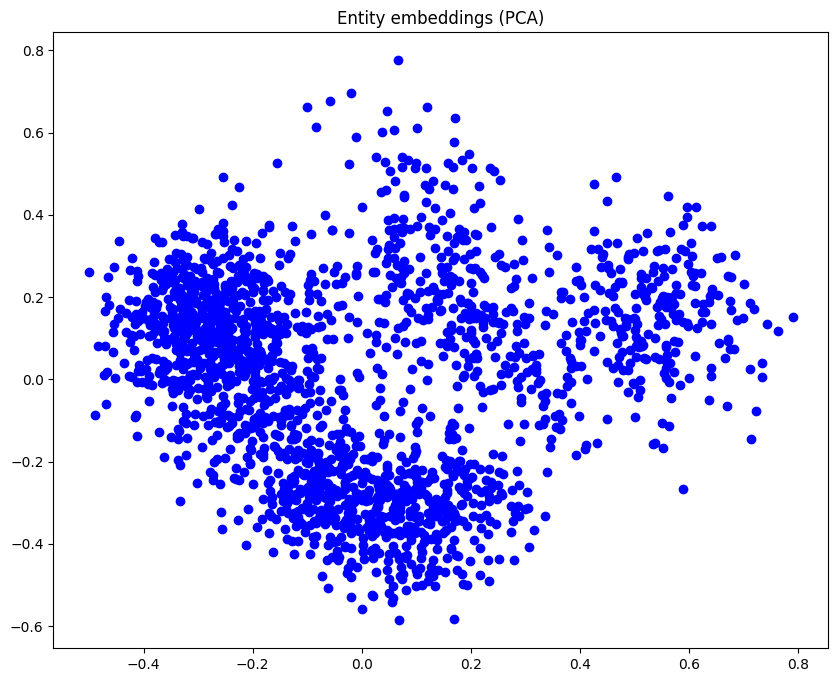

In [47]:
pca = PCA(n_components=2)

emb2d = pca.fit_transform(entity_embeddings)

plt.figure(figsize=(10,8))

for entity, idx in dataset.entity_to_id.items():

    plt.scatter(
        emb2d[idx,0],
        emb2d[idx,1], c='b'
    )

plt.title("Entity embeddings (PCA)")
plt.show()

### **Finding similar entities**

We can use cosine similarity to find similar entities in the embedding space.

In [50]:
entity_embeddings = model.entity_representations[0]().detach().cpu()
relation_embeddings = model.relation_representations[0]().detach().cpu()

entity_to_id = transe_result.training.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

target_entity = "Q1005"
target_id = entity_to_id[target_entity]

target_vector = entity_embeddings[target_id].unsqueeze(0)

# Compute Cosine Similarity against all entities
cos_sim = torch.nn.CosineSimilarity(dim=1)
similarities = cos_sim(target_vector, entity_embeddings)

# Display the top 5 most similar entities in the embedding space
top_k = torch.topk(similarities, k=5)

print(f"Most similar entities to {target_entity}:")
for score, idx in zip(top_k.values, top_k.indices):
    entity_label = id_to_entity[idx.item()]
    print(f" * {entity_label.upper()}: {score.item():.4f}")

Most similar entities to Q1005:
 * Q1005: 1.0000
 * Q1037: 0.6139
 * Q1036: 0.5753
 * Q114: 0.5469
 * Q1044: 0.5322


### **Link Prediction**

We can infer missing information for KG completion.

In [55]:

genre_pred = predict_target(
    model=transe_result.model,
    head="Q2831", #Michael Jackson
    relation="P136", #genre
    triples_factory=transe_result.training
)

top_genre_qids = genre_pred.df['tail_label'].head(3).tolist()


print("Which genre is associaed with Michael Jackson?")
for qid in top_genre_qids:
    print(qid)

Which genre is associaed with Michael Jackson?
Q45981
Q131272
Q164444


### **Downstream task**

You can use the resulting embeddings as input to a ML algorithm of your choice!